# HW2.5 GPU Performance Measurements

This notebook performs the complete HW2.5 experiment on an assigned NVIDIA GeForce RTX 5060 family GPU.

Run the notebook on the RTX 5060 family workstation, from top to bottom. Do not run the performance cells on a different computer and submit those measurements. The notebook creates the required `system/`, `results/`, `figures/`, and `logs/` folders automatically.

Required experiments:

1. Hardware and CUDA verification
2. FP32, TF32, FP16, and BF16 matrix multiplication throughput
3. FP32 elementwise-add effective memory bandwidth
4. Naive and fused BF16 attention, including OOM boundary testing
5. A 20-minute sustained GPU workload sampled every 5 seconds
6. Figures, metrics, run log, and AI-use disclosure

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import gc
import math
import os
import statistics
import subprocess
import time
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
ROOT = Path.cwd()
SYSTEM_DIR = ROOT / "system"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
LOGS_DIR = ROOT / "logs"
for folder in (SYSTEM_DIR, RESULTS_DIR, FIGURES_DIR, LOGS_DIR):
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable. Run this notebook on the target RTX 5060 family workstation.")

In [5]:
MATMUL_SIZES = [1024, 2048, 4096, 8192]
MATMUL_DTYPES = {
    "FP32": torch.float32,
    "FP16": torch.float16,
    "BF16": torch.bfloat16,
}
ATTENTION_SEQUENCES = [1024, 2048, 4096, 6144, 8192]
ATTENTION_BATCH = 4
ATTENTION_HEADS = 32
ATTENTION_HEAD_DIM = 128
ATTENTION_DTYPE = torch.bfloat16
SUSTAINED_DURATION_SECONDS = 20 * 60
SUSTAINED_SAMPLE_INTERVAL_SECONDS = 5
TARGET_GPU_FAMILY = "5060"
GPU_LOG_SUFFIX = "5060"



DEVICE = torch.device("cuda:0")
GPU_NAME = torch.cuda.get_device_name(0)
if TARGET_GPU_FAMILY not in GPU_NAME:
    raise RuntimeError(f"This notebook requires an RTX 5060 family GPU, including the Ti and laptop variants; detected: {GPU_NAME}")

print("Notebook root:", ROOT)
print("GPU:", GPU_NAME)
print("PyTorch:", torch.__version__)
print("CUDA runtime used by PyTorch:", torch.version.cuda)

Notebook root: /home/akash/dev/denisha
GPU: NVIDIA GeForce RTX 5060 Ti
PyTorch: 2.14.0+cu130
CUDA runtime used by PyTorch: 13.0


In [6]:
# Cell 2 : capture the actual hardware information
def command_output(command):
    return subprocess.check_output(command, text=True, stderr=subprocess.STDOUT)

try:
    nvidia_smi_text = command_output(["nvidia-smi", "-q"])
except Exception as exc:
    raise RuntimeError("nvidia-smi is required for the hardware record.") from exc

(SYSTEM_DIR / "nvidia_smi_5060.txt").write_text(nvidia_smi_text, encoding="utf-8")

query = command_output([
    "nvidia-smi", "--query-gpu=name,uuid,driver_version,memory.total,power.limit",
    "--format=csv,noheader,nounits"
]).strip()
parts = [p.strip() for p in query.split(",")]
GPU_UUID = parts[1]
DRIVER_VERSION = parts[2]
MEMORY_TOTAL_MB = parts[3]
POWER_LIMIT_W = parts[4]

properties = torch.cuda.get_device_properties(0)
print("GPU:", GPU_NAME)
print("GPU UUID:", GPU_UUID)
print("Driver version:", DRIVER_VERSION)
print("VRAM from PyTorch:", round(properties.total_memory / 1024**3, 2), "GB")
print("nvidia-smi memory total:", MEMORY_TOTAL_MB, "MiB")
print("Configured power limit:", POWER_LIMIT_W, "W")
print("Saved:", SYSTEM_DIR / "nvidia_smi_5060.txt")

GPU: NVIDIA GeForce RTX 5060 Ti
GPU UUID: GPU-af815c34-e868-2ca8-0057-81c8ac28573e
Driver version: 616.92
VRAM from PyTorch: 15.9 GB
nvidia-smi memory total: 16311 MiB
Configured power limit: 180.00 W
Saved: /home/akash/dev/denisha/system/nvidia_smi_5060.txt


## Part B : Matrix multiplication throughput

For square matrices, the approximate floating-point operation count is `2N³`. TFLOPS is calculated as `2N³ / elapsed_seconds / 10¹²`. TF32 is tested by enabling TensorFloat-32 for FP32 matrix multiplication; it is recorded separately from ordinary FP32.

In [7]:
# Cell 3 : matrix multiplication benchmark
def synchronize():
    torch.cuda.synchronize(DEVICE)

def cleanup_cuda():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)

def benchmark_matmul_one(n, label, dtype, tf32=False, warmups=5, repeats=20):
    previous_tf32 = torch.backends.cuda.matmul.allow_tf32
    torch.backends.cuda.matmul.allow_tf32 = tf32
    try:
        a = torch.randn((n, n), device=DEVICE, dtype=dtype)
        b = torch.randn((n, n), device=DEVICE, dtype=dtype)
        for _ in range(warmups):
            c = a @ b
        synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(repeats):
            c = a @ b
        end.record()
        synchronize()
        elapsed_seconds = start.elapsed_time(end) / 1000.0 / repeats
        tflops = (2 * n**3) / elapsed_seconds / 1e12
        return {
            "gpu_uuid": GPU_UUID, "gpu_name": GPU_NAME, "matrix_size": n,
            "precision": label, "dtype": str(dtype).replace("torch.", ""),
            "tf32_enabled": tf32, "elapsed_ms": elapsed_seconds * 1000,
            "tflops": tflops, "status": "SUCCESS",
        }
    except torch.cuda.OutOfMemoryError:
        return {
            "gpu_uuid": GPU_UUID, "gpu_name": GPU_NAME, "matrix_size": n,
            "precision": label, "dtype": str(dtype).replace("torch.", ""),
            "tf32_enabled": tf32, "elapsed_ms": "", "tflops": "", "status": "OOM",
        }
    finally:
        for name in ("a", "b", "c"):
            if name in locals():
                del locals()[name]
        torch.backends.cuda.matmul.allow_tf32 = previous_tf32
        cleanup_cuda()

matmul_rows = []
for n in MATMUL_SIZES:
    for label, dtype in MATMUL_DTYPES.items():
        matmul_rows.append(benchmark_matmul_one(n, label, dtype))
    matmul_rows.append(benchmark_matmul_one(n, "TF32", torch.float32, tf32=True))

matmul_df = pd.DataFrame(matmul_rows)
matmul_df.to_csv(RESULTS_DIR / "matmul_results.csv", index=False)
display(matmul_df)
print("Saved:", RESULTS_DIR / "matmul_results.csv")

,gpu_uuid,gpu_name,matrix_size,precision,dtype,tf32_enabled,elapsed_ms,tflops,status
0,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,1024,FP32,float32,False,0.164928,13.020735,SUCCESS
1,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,1024,FP16,float16,False,0.058080,36.974581,SUCCESS
2,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,1024,BF16,bfloat16,False,0.061379,34.987156,SUCCESS
3,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,1024,TF32,float32,True,0.108646,19.765805,SUCCESS
4,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,2048,FP32,float32,False,1.064734,16.135357,SUCCESS
5,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,2048,FP16,float16,False,0.382610,44.901824,SUCCESS
6,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,2048,BF16,bfloat16,False,0.371189,46.283371,SUCCESS
7,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,2048,TF32,float32,True,0.830237,20.692734,SUCCESS
8,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,4096,FP32,float32,False,8.079611,17.010590,SUCCESS
9,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,4096,FP16,float16,False,2.908248,47.258334,SUCCESS


Saved: /home/akash/dev/denisha/results/matmul_results.csv


## Part C : Effective memory bandwidth

The elementwise operation is `C = A + B`. It reads two FP32 arrays and writes one FP32 array, so the transferred bytes are `3 × number_of_elements × 4`. Effective bandwidth is transferred bytes divided by elapsed time.

In [8]:
# Cell 4 : FP32 elementwise-add bandwidth benchmark
def benchmark_bandwidth(elements=256 * 1024 * 1024, warmups=5, repeats=20):
    try:
        a = torch.randn(elements, device=DEVICE, dtype=torch.float32)
        b = torch.randn(elements, device=DEVICE, dtype=torch.float32)
        for _ in range(warmups):
            c = a + b
        synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(repeats):
            c = a + b
        end.record()
        synchronize()
        elapsed_seconds = start.elapsed_time(end) / 1000.0 / repeats
        bytes_moved = 3 * elements * torch.tensor([], dtype=torch.float32).element_size()
        bandwidth_gbs = bytes_moved / elapsed_seconds / 1e9
        result = {"gpu_uuid": GPU_UUID, "gpu_name": GPU_NAME, "operation": "FP32 elementwise add",
                  "elements": elements, "bytes_moved": bytes_moved, "elapsed_ms": elapsed_seconds * 1000,
                  "effective_bandwidth_gb_s": bandwidth_gbs, "status": "SUCCESS"}
    except torch.cuda.OutOfMemoryError:
        result = {"gpu_uuid": GPU_UUID, "gpu_name": GPU_NAME, "operation": "FP32 elementwise add",
                  "elements": elements, "bytes_moved": "", "elapsed_ms": "",
                  "effective_bandwidth_gb_s": "", "status": "OOM"}
    finally:
        for name in ("a", "b", "c"):
            if name in locals():
                del locals()[name]
        cleanup_cuda()
    return result

bandwidth_df = pd.DataFrame([benchmark_bandwidth()])
bandwidth_df.to_csv(RESULTS_DIR / "bandwidth_results.csv", index=False)
display(bandwidth_df)
print("Saved:", RESULTS_DIR / "bandwidth_results.csv")

,gpu_uuid,gpu_name,operation,elements,bytes_moved,elapsed_ms,effective_bandwidth_gb_s,status
0,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,NVIDIA GeForce RTX 5060 Ti,FP32 elementwise add,268435456,3221225472,9.322485,345.532936,SUCCESS


Saved: /home/akash/dev/denisha/results/bandwidth_results.csv


## Part D : Attention memory behavior

The naive implementation explicitly creates the `B × H × N × N` attention-score tensor. The fused implementation uses `torch.nn.functional.scaled_dot_product_attention`, which can select an optimized backend and avoid materializing the complete score matrix. OOM results are expected at sufficiently large sequence lengths.

In [9]:
# Cell 5 : naive and fused attention benchmark
def benchmark_attention_one(sequence, implementation, repeats=3):
    q = k = v = output = scores = weights = None
    try:
        cleanup_cuda()
        q = torch.randn((ATTENTION_BATCH, ATTENTION_HEADS, sequence, ATTENTION_HEAD_DIM), device=DEVICE, dtype=ATTENTION_DTYPE)
        k = torch.randn_like(q)
        v = torch.randn_like(q)
        for _ in range(2):
            if implementation == "naive":
                scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(ATTENTION_HEAD_DIM)
                weights = torch.softmax(scores, dim=-1)
                output = torch.matmul(weights, v)
            else:
                output = F.scaled_dot_product_attention(q, k, v)
        synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(repeats):
            if implementation == "naive":
                scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(ATTENTION_HEAD_DIM)
                weights = torch.softmax(scores, dim=-1)
                output = torch.matmul(weights, v)
            else:
                output = F.scaled_dot_product_attention(q, k, v)
        end.record()
        synchronize()
        latency_ms = start.elapsed_time(end) / repeats
        peak_memory_gb = torch.cuda.max_memory_allocated(DEVICE) / 1024**3
        return {"gpu_uuid": GPU_UUID, "implementation": implementation, "batch": ATTENTION_BATCH,
                "heads": ATTENTION_HEADS, "head_dim": ATTENTION_HEAD_DIM, "dtype": "BF16",
                "sequence": sequence, "status": "SUCCESS", "latency_ms": latency_ms,
                "peak_memory_gb": peak_memory_gb}
    except torch.cuda.OutOfMemoryError:
        return {"gpu_uuid": GPU_UUID, "implementation": implementation, "batch": ATTENTION_BATCH,
                "heads": ATTENTION_HEADS, "head_dim": ATTENTION_HEAD_DIM, "dtype": "BF16",
                "sequence": sequence, "status": "OOM", "latency_ms": "", "peak_memory_gb": ""}
    finally:
        del q, k, v, output, scores, weights
        cleanup_cuda()

def run_attention(implementation, sequences=ATTENTION_SEQUENCES):
    return [benchmark_attention_one(n, implementation) for n in sequences]

naive_attention_df = pd.DataFrame(run_attention("naive"))
fused_attention_df = pd.DataFrame(run_attention("fused"))
naive_attention_df.to_csv(RESULTS_DIR / "attention_naive.csv", index=False)
fused_attention_df.to_csv(RESULTS_DIR / "attention_fused.csv", index=False)
display(naive_attention_df)
display(fused_attention_df)

[W918 11:16:12.086013068 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 9663676416 bytes (free: 0, total: 17074421760).
[W918 11:16:13.096123122 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 9663676416 bytes (free: 0, total: 17074421760).
[W918 11:16:18.321640692 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 0, total: 17074421760).
[W918 11:16:21.706786426 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 0, total: 17074421760).


,gpu_uuid,implementation,batch,heads,head_dim,dtype,sequence,status,latency_ms,peak_memory_gb
0,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,1024,SUCCESS,7.011627,1.15625
1,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,2048,SUCCESS,26.583766,4.28125
2,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,4096,SUCCESS,714.08724,16.53125
3,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,6144,OOM,,
4,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,8192,OOM,,


,gpu_uuid,implementation,batch,heads,head_dim,dtype,sequence,status,latency_ms,peak_memory_gb
0,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,fused,4,32,128,BF16,1024,SUCCESS,9.828384,0.187989
1,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,fused,4,32,128,BF16,2048,SUCCESS,23.265055,0.344728
2,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,fused,4,32,128,BF16,4096,SUCCESS,26.040108,0.658204
3,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,fused,4,32,128,BF16,6144,SUCCESS,58.271189,0.971681
4,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,fused,4,32,128,BF16,8192,SUCCESS,102.940145,1.285157


### OOM-boundary refinement

The next cell automatically refines each observed success/OOM bracket by testing midpoint lengths until the bracket is at most 128 tokens wide. It reports a bracket, not an invented exact limit. If the initial tested range contains no OOM, the notebook records that no OOM was observed in the tested range; no unsupported limit is created.

In [10]:
# Cell 6 : automatic OOM-boundary refinement
REFINEMENT_RESOLUTION = 128

def refine_attention_boundary(initial_df, implementation, filename):
    tested_rows = []
    low_values = initial_df.loc[initial_df.status == "SUCCESS", "sequence"].tolist()
    high_values = initial_df.loc[initial_df.status == "OOM", "sequence"].tolist()
    if not low_values or not high_values:
        print(f"{implementation}: no success/OOM bracket in the initial tested range; no refinement run.")
        return pd.DataFrame()
    low = max(low_values)
    high = min(high_values)
    while high - low > REFINEMENT_RESOLUTION:
        midpoint = ((low + high) // 2 // REFINEMENT_RESOLUTION) * REFINEMENT_RESOLUTION
        if midpoint <= low or midpoint >= high:
            break
        result = benchmark_attention_one(midpoint, implementation)
        tested_rows.append(result)
        if result["status"] == "SUCCESS":
            low = midpoint
        else:
            high = midpoint
        print(f"{implementation}: tested {midpoint}; bracket is {low} success to {high} OOM")
    refined_df = pd.DataFrame(tested_rows)
    refined_df.to_csv(RESULTS_DIR / filename, index=False)
    display(refined_df)
    return refined_df

naive_refinement_df = refine_attention_boundary(
    naive_attention_df, "naive", "attention_naive_refinement.csv"
)
fused_refinement_df = refine_attention_boundary(
    fused_attention_df, "fused", "attention_fused_refinement.csv"
)

naive_attention_all_df = pd.concat([naive_attention_df, naive_refinement_df], ignore_index=True)
fused_attention_all_df = pd.concat([fused_attention_df, fused_refinement_df], ignore_index=True)

[W918 11:16:29.829457266 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 6710886400 bytes (free: 0, total: 17074421760).
[W918 11:16:30.890628120 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 6710886400 bytes (free: 0, total: 17074421760).


naive: tested 5120; bracket is 4096 success to 5120 OOM
naive: tested 4608; bracket is 4608 success to 5120 OOM
naive: tested 4864; bracket is 4864 success to 5120 OOM


[W918 11:16:48.570503896 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 6379536384 bytes (free: 0, total: 17074421760).


naive: tested 4992; bracket is 4992 success to 5120 OOM


,gpu_uuid,implementation,batch,heads,head_dim,dtype,sequence,status,latency_ms,peak_memory_gb
0,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,5120,OOM,,
1,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,4608,SUCCESS,1100.581543,20.84375
2,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,4864,SUCCESS,1470.413737,23.1875
3,GPU-af815c34-e868-2ca8-0057-81c8ac28573e,naive,4,32,128,BF16,4992,SUCCESS,2762.030924,24.40625


fused: no success/OOM bracket in the initial tested range; no refinement run.


## Figures

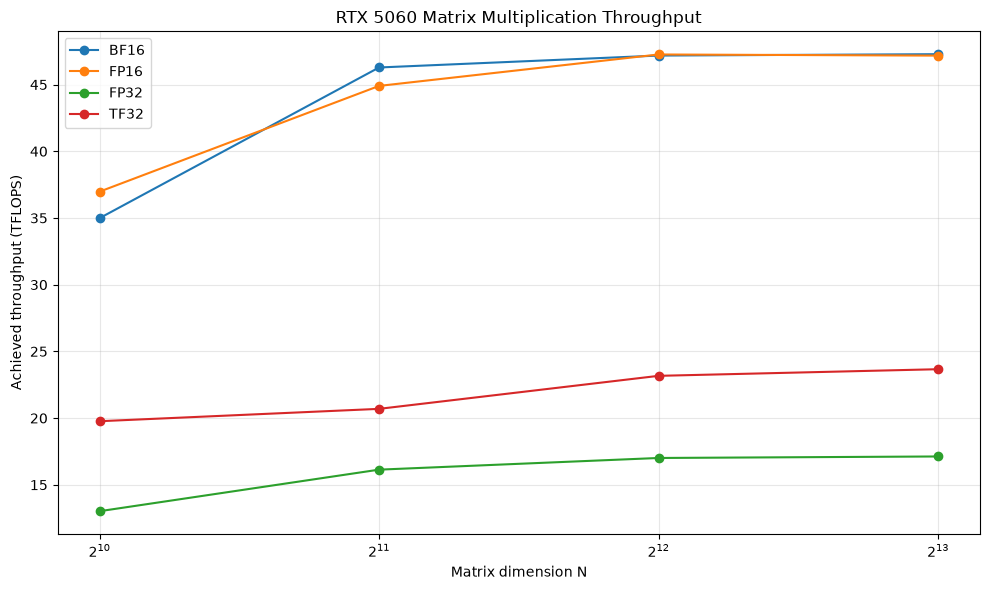

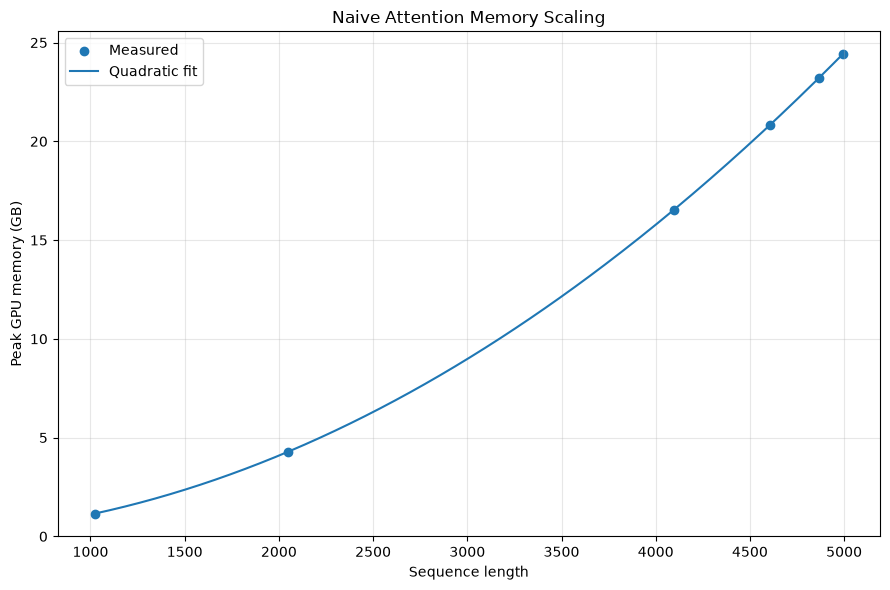

Measured quadratic coefficient: 9.5367431641e-07 GB/token²


In [11]:
# Cell 7 : matrix throughput and attention-memory figures
successful_matmul = matmul_df[matmul_df.status == "SUCCESS"].copy()
plt.figure(figsize=(10, 6))
for precision, group in successful_matmul.groupby("precision"):
    plt.plot(group.matrix_size, group.tflops, marker="o", label=precision)
plt.xlabel("Matrix dimension N")
plt.ylabel("Achieved throughput (TFLOPS)")
plt.title("RTX 5060 Matrix Multiplication Throughput")
plt.xscale("log", base=2)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matmul_tflops.png", dpi=300)
plt.show()

success = naive_attention_all_df[naive_attention_all_df.status == "SUCCESS"].copy()
if len(success) >= 3:
    x = success.sequence.to_numpy(dtype=float)
    y = success.peak_memory_gb.to_numpy(dtype=float)
    degree = 2 if len(success) >= 3 else 1
    a, b, c = np.polyfit(x, y, degree) if degree == 2 else (0, *np.polyfit(x, y, 1))
    if degree == 2:
        quadratic_coefficient = float(a)
        y_curve = a * np.linspace(x.min(), x.max(), 300)**2 + b * np.linspace(x.min(), x.max(), 300) + c
    else:
        quadratic_coefficient = float("nan")
        curve_x = np.linspace(x.min(), x.max(), 300)
        y_curve = b * curve_x + c
    curve_x = np.linspace(x.min(), x.max(), 300)
    plt.figure(figsize=(9, 6))
    plt.scatter(x, y, label="Measured")
    plt.plot(curve_x, y_curve, label="Quadratic fit" if degree == 2 else "Linear fit")
    plt.xlabel("Sequence length")
    plt.ylabel("Peak GPU memory (GB)")
    plt.title("Naive Attention Memory Scaling")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "attention_memory.png", dpi=300)
    plt.show()
    print(f"Measured quadratic coefficient: {quadratic_coefficient:.10e} GB/token²")
else:
    quadratic_coefficient = float("nan")
    print("Not enough successful naive-attention points for a fit.")

## Part E : 20-minute sustained GPU experiment

This cell must run for the full 20 minutes. It samples `nvidia-smi` every 5 seconds and continuously performs BF16 matrix multiplication. Close unrelated GPU workloads first, and do not stop the cell early. The actual configured power limit is taken from this machine's hardware capture.

In [12]:
# Cell 8 : sustained workload and thermal/throughput logs
SUSTAINED_N = 4096
throughput_records = []
running = True

def get_gpu_sample():
    text = command_output([
        "nvidia-smi", "--query-gpu=timestamp,uuid,clocks.sm,clocks.mem,temperature.gpu,power.draw,utilization.gpu",
        "--format=csv,noheader,nounits"
    ]).strip()
    return [item.strip() for item in text.split(",")]

def monitor_gpu(start_time):
    global running
    with open(LOGS_DIR / "thermal_5060.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["elapsed_seconds", "timestamp", "gpu_uuid", "sm_clock_mhz", "memory_clock_mhz",
                         "temperature_c", "power_w", "utilization_percent"])
        while running:
            elapsed = time.time() - start_time
            try:
                writer.writerow([elapsed, *get_gpu_sample()])
                f.flush()
            except Exception as exc:
                print("Monitoring error:", repr(exc))
            time.sleep(SUSTAINED_SAMPLE_INTERVAL_SECONDS)

A = torch.randn((SUSTAINED_N, SUSTAINED_N), device=DEVICE, dtype=torch.bfloat16)
B = torch.randn_like(A)
for _ in range(10):
    C = A @ B
synchronize()
start_total = time.time()
monitor_thread = threading.Thread(target=monitor_gpu, args=(start_total,), daemon=True)
monitor_thread.start()
try:
    while time.time() - start_total < SUSTAINED_DURATION_SECONDS:
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        C = A @ B
        end.record()
        synchronize()
        seconds = start.elapsed_time(end) / 1000.0
        tflops = (2 * SUSTAINED_N**3) / seconds / 1e12
        throughput_records.append((time.time() - start_total, tflops))
finally:
    running = False
    monitor_thread.join()
    del A, B, C
    cleanup_cuda()

with open(LOGS_DIR / "throughput_5060.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["elapsed_seconds", "tflops"])
    writer.writerows(throughput_records)

first = [value for elapsed, value in throughput_records if elapsed <= 30]
final = [value for elapsed, value in throughput_records if elapsed >= SUSTAINED_DURATION_SECONDS - 300]
if not first or not final:
    raise RuntimeError("The sustained run did not collect enough data for the required comparison.")
peak_initial = max(first)
steady_state = statistics.mean(final)
steady_percentage = steady_state / peak_initial * 100
print("Peak first 30 seconds:", peak_initial, "TFLOPS")
print("Final 5-minute average:", steady_state, "TFLOPS")
print("Steady state / peak:", steady_percentage, "%")

Peak first 30 seconds: 47.912442200148135 TFLOPS
Final 5-minute average: 46.28759090430429 TFLOPS
Steady state / peak: 96.60870700546586 %


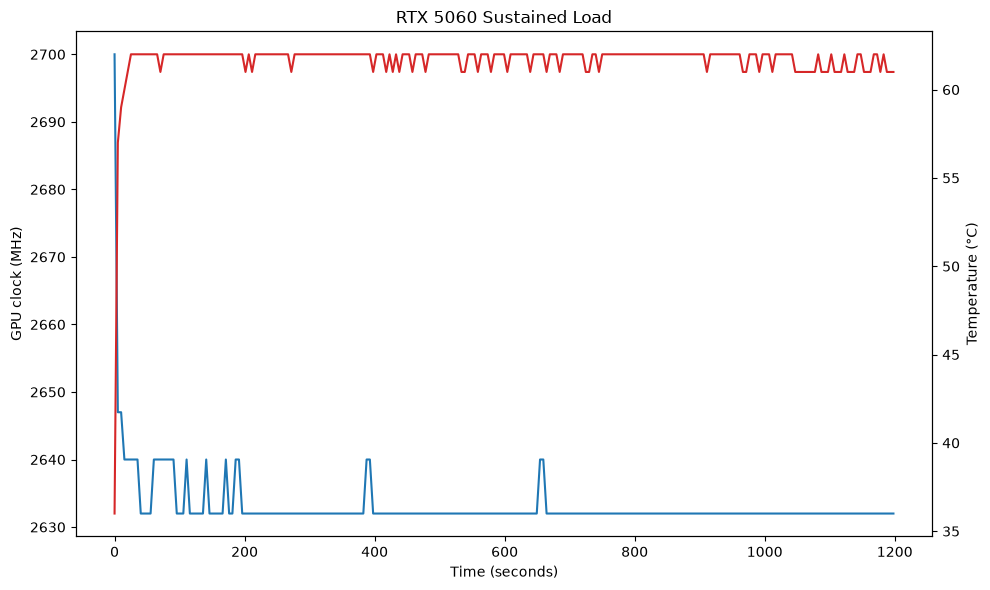

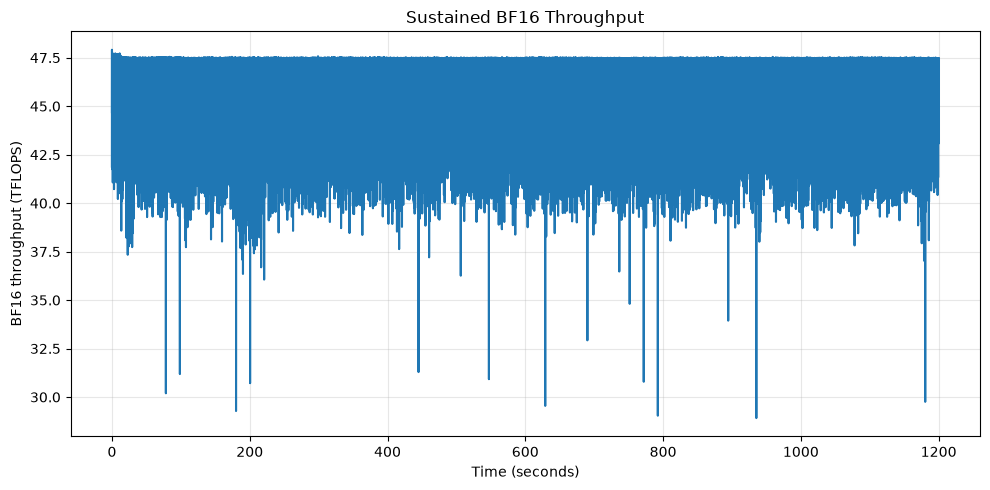

Saved thermal.png and sustained_throughput.png


In [13]:
# Cell 9 : thermal and sustained-throughput figures
thermal_df = pd.read_csv(LOGS_DIR / "thermal_5060.csv")
throughput_df = pd.read_csv(LOGS_DIR / "throughput_5060.csv")

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(thermal_df.elapsed_seconds, thermal_df.sm_clock_mhz, label="GPU clock")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("GPU clock (MHz)")
ax2 = ax1.twinx()
ax2.plot(thermal_df.elapsed_seconds, thermal_df.temperature_c, color="tab:red", label="Temperature")
ax2.set_ylabel("Temperature (°C)")
plt.title("RTX 5060 Sustained Load")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "thermal.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(throughput_df.elapsed_seconds, throughput_df.tflops)
plt.xlabel("Time (seconds)")
plt.ylabel("BF16 throughput (TFLOPS)")
plt.title("Sustained BF16 Throughput")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sustained_throughput.png", dpi=300)
plt.show()

print("Saved thermal.png and sustained_throughput.png")

## Part F : metrics and written analysis

The next cell writes `METRICS.md` using only measurements collected by this notebook. Review the generated file and replace the qualitative placeholders about throttling only after examining the thermal graph and the `Clocks Event Reasons` section in `system/nvidia_smi_5060.txt`.

In [14]:
# Cell 10 : generate the required metrics file from actual results
successful_bf16 = matmul_df[(matmul_df.precision == "BF16") & (matmul_df.status == "SUCCESS")]
peak_bf16 = float(successful_bf16.tflops.max()) if not successful_bf16.empty else float("nan")
bandwidth_value = float(bandwidth_df.iloc[0].effective_bandwidth_gb_s) if bandwidth_df.iloc[0].status == "SUCCESS" else float("nan")

# NVIDIA publishes the RTX 5060 architecture, memory, CUDA core count, and boost clock.
# It does not publish one directly comparable dense BF16 TFLOPS figure for this table.
# The notebook therefore reports the measured BF16 result without inventing a theoretical percentage.
THEORETICAL_BF16_TFLOPS = None
percent_theoretical = float("nan")
percent_theoretical_display = "Not reported because no directly comparable official BF16 TFLOPS reference is published"

thermal_for_metrics = pd.read_csv(LOGS_DIR / "thermal_5060.csv")
thermal_for_metrics["sm_clock_mhz"] = pd.to_numeric(thermal_for_metrics["sm_clock_mhz"], errors="coerce")
thermal_for_metrics["temperature_c"] = pd.to_numeric(thermal_for_metrics["temperature_c"], errors="coerce")
initial_clock = thermal_for_metrics.loc[thermal_for_metrics.elapsed_seconds <= 30, "sm_clock_mhz"].median()
final_clock = thermal_for_metrics.loc[thermal_for_metrics.elapsed_seconds >= SUSTAINED_DURATION_SECONDS - 300, "sm_clock_mhz"].median()
clock_drop_percent = (initial_clock - final_clock) / initial_clock * 100
possible_onset = thermal_for_metrics.loc[
    thermal_for_metrics.sm_clock_mhz <= initial_clock * 0.95, "elapsed_seconds"
]
if clock_drop_percent > 5 and not possible_onset.empty:
    throttle_onset_display = f"Possible sustained clock reduction near {possible_onset.iloc[0]:.0f} seconds; review thermal and power evidence"
else:
    throttle_onset_display = "No clear sustained throttling signature from the conservative clock check"

def bracket(df):
    success_values = df.loc[df.status == "SUCCESS", "sequence"].tolist()
    oom_values = df.loc[df.status == "OOM", "sequence"].tolist()
    return (f"largest tested success: {max(success_values)}; smallest tested failure: {min(oom_values)}"
            if success_values and oom_values else
            f"largest tested success: {max(success_values)}; no OOM observed in tested range" if success_values else
            f"no successful length; smallest tested failure: {min(oom_values)}" if oom_values else "no result")

metrics = f"""# HW2.5 GPU Performance Measurements

GPU: {GPU_NAME}
GPU UUID: {GPU_UUID}

## Table HW2.5.1

| Measurement | {GPU_NAME} | Notes |
|---|---:|---|
| Peak achieved TFLOPS (BF16) | {peak_bf16:.6f} | Best measured BF16 GEMM result |
| % theoretical peak (BF16) | {percent_theoretical_display} | The exact desktop or laptop reference must match the measured GPU variant |
| Effective bandwidth (GB/s) | {bandwidth_value:.6f} | FP32 elementwise add |
| Naive attention OOM length | {bracket(naive_attention_all_df)} | Tested bracket, not an invented exact limit |
| Fused attention OOM length | {bracket(fused_attention_all_df)} | Tested bracket, not an invented exact limit |
| Steady state / peak throughput | {steady_percentage:.2f}% | Final 5 minutes / first 30 seconds peak |
| Throttle assessment | {throttle_onset_display} | Review the thermal graph and NVIDIA clock-event reasons before submission |

## Analysis

### Precision

Throughput should be interpreted together with matrix size. Small matrices may underutilize the GPU because launch and scheduling overheads are large relative to the available parallel work. FP16 and BF16 can use the RTX 5060 family Tensor Cores, while FP32 and TF32 use different arithmetic paths. At larger sizes, the measured curves show whether throughput approaches a plateau.

### Bandwidth

The elementwise addition has low arithmetic intensity: each output requires little computation but multiple values must be read or written. Its performance is therefore primarily constrained by memory movement. Matrix multiplication reuses matrix values many times and has much higher arithmetic intensity, so it is more compute-oriented.

### Attention

Naive attention stores a sequence-by-sequence score matrix, so its memory usage grows approximately quadratically with sequence length. Fused attention avoids materializing that complete matrix in global memory, reducing peak VRAM use even though the underlying attention computation still has approximately quadratic computational work.

Measured naive-attention quadratic coefficient from the plot cell: {quadratic_coefficient:.10e} GB/token².

### Sustained load

The final five-minute throughput was {steady_percentage:.2f}% of the peak throughput measured during the first 30 seconds. The notebook provides a conservative clock-based assessment, which should be checked against `thermal.png`, `thermal_5060.csv`, and the NVIDIA clock-event reasons.
"""
(ROOT / "METRICS.md").write_text(metrics, encoding="utf-8")
print(metrics)

# HW2.5 GPU Performance Measurements

GPU: NVIDIA GeForce RTX 5060 Ti
GPU UUID: GPU-af815c34-e868-2ca8-0057-81c8ac28573e

## Table HW2.5.1

| Measurement | NVIDIA GeForce RTX 5060 Ti | Notes |
|---|---:|---|
| Peak achieved TFLOPS (BF16) | 47.280220 | Best measured BF16 GEMM result |
| % theoretical peak (BF16) | Not reported because no directly comparable official BF16 TFLOPS reference is published | The exact desktop or laptop reference must match the measured GPU variant |
| Effective bandwidth (GB/s) | 345.532936 | FP32 elementwise add |
| Naive attention OOM length | largest tested success: 4992; smallest tested failure: 5120 | Tested bracket, not an invented exact limit |
| Fused attention OOM length | largest tested success: 8192; no OOM observed in tested range | Tested bracket, not an invented exact limit |
| Steady state / peak throughput | 96.61% | Final 5 minutes / first 30 seconds peak |
| Throttle assessment | No clear sustained throttling signature from the conservative 

In [15]:
# Cell 11 : write run log and AI disclosure
now = datetime.now(timezone.utc).astimezone().isoformat(timespec="seconds")
run_log = f"""# HW2.5 GPU RUN LOG

Date of notebook execution: {now}
Machine GPU: {GPU_NAME}
GPU UUID: {GPU_UUID}
Driver version: {DRIVER_VERSION}
PyTorch: {torch.__version__}
CUDA runtime: {torch.version.cuda}
VRAM: {MEMORY_TOTAL_MB} MiB
Configured power limit: {POWER_LIMIT_W} W

## Experiments completed

- Hardware capture: `system/nvidia_smi_5060.txt`
- Matrix multiplication: `results/matmul_results.csv`
- Bandwidth: `results/bandwidth_results.csv`
- Naive attention: `results/attention_naive.csv`
- Fused attention: `results/attention_fused.csv`
- Sustained thermal log: `logs/thermal_5060.csv`
- Sustained throughput log: `logs/throughput_5060.csv`
- Figures: `figures/matmul_tflops.png`, `figures/attention_memory.png`, `figures/thermal.png`, `figures/sustained_throughput.png`

Configuration: attention batch={ATTENTION_BATCH}, heads={ATTENTION_HEADS}, head dimension={ATTENTION_HEAD_DIM}, dtype=BF16; sustained duration={SUSTAINED_DURATION_SECONDS} seconds; sample interval={SUSTAINED_SAMPLE_INTERVAL_SECONDS} seconds.

Reservation record and actual GPU hours: ENTER THE VALUES FROM YOUR COMPUTE-RESERVATION SYSTEM. This notebook cannot know those values automatically.
"""
(ROOT / "RUN_LOG.txt").write_text(run_log, encoding="utf-8")

ai_use = """# AI_USE.md

I used ChatGPT as a programming and explanation assistant for this assignment. It helped organize the notebook, design the PyTorch benchmark workflow, explain TFLOPS, arithmetic intensity, memory bandwidth, and attention memory scaling, and improve the clarity of the written analysis. All GPU experiments, numerical measurements, GPU identification, NVIDIA capture, thermal data, figures, and reported performance results were generated by running this notebook on the assigned RTX 5060.
"""
(ROOT / "AI_USE.md").write_text(ai_use, encoding="utf-8")
print("Wrote METRICS.md, RUN_LOG.txt, and AI_USE.md")

Wrote METRICS.md, RUN_LOG.txt, and AI_USE.md


## Final submission checklist

Before submitting, confirm that the repository contains:

- `HW2_5_GPU_Assignment.ipynb` with outputs from the RTX 5060 family
- `system/nvidia_smi_5060.txt`
- the reservation record and actual GPU hours in `RUN_LOG.txt`
- all CSV files in `results/`
- all logs in `logs/`
- all figures in `figures/`
- `METRICS.md`, `RUN_LOG.txt`, and `AI_USE.md`
- the source notebook and any required README or repository files
- Git tag `hw2-5`

Do not submit `TBD`, placeholder UUIDs, example performance numbers, or an unrun 20-minute experiment. The OOM result must be reported as a tested success/failure bracket unless adjacent lengths were actually tested.